# Import Libraries

In [1]:
import os
import math
import random
import shutil
import itertools
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import pwlf
from multiprocessing import Pool, cpu_count
from tqdm import tqdm, trange

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

import brevitas.nn as qnn
from brevitas.nn import QuantLinear, QuantReLU, QuantConv2d
from brevitas.quant.binary import SignedBinaryActPerTensorConst
from brevitas.quant.binary import SignedBinaryWeightPerTensorConst
from brevitas.inject.enum import QuantType
from brevitas.quant_tensor.int_quant_tensor import IntQuantTensor
from brevitas.function.ops_ste import round_ste

# Network Definition

#### Neuron number and precision in each layer listed in this area for the MLP used in MNIST classification

In [2]:
kernel_num_CONV_layer_0_0 = 64
kernel_num_CONV_layer_0_1 = 64

kernel_num_CONV_layer_1_0 = 128
kernel_num_CONV_layer_1_1 = 128

kernel_num_CONV_layer_2_0 = 256
kernel_num_CONV_layer_2_1 = 256

neuron_num_FC_layer_0 = 512
neuron_num_FC_layer_1 = 512
neuron_num_OUT_layer  = 10

#### Hyperparameters setting here.

In [3]:
epochs = 100
batch_sizes = [128, 256]
dropout_rates = [0.0, 0.05, 0.1]
lr_max_pool = [0.001, 0.0005]
lr_min_pool = [0.00001, 0.000001]

#### GPU selection. After decided which GPU to train, don't change it before completing the training

In [4]:
GPU_device = "cuda:1"

#### Training date output folder path, for different network model setting, please change the name of save_path

In [5]:
save_path     = "CNV_float"

project_root  = os.path.abspath(".")
dataset_root  = os.path.join(project_root, "dataset")
train_root    = os.path.join(project_root, "train")
output_root   = os.path.join(train_root, save_path)
report_root  = os.path.join(project_root, "report")

print("Dataset Download Path: ", dataset_root, "\n")
print("Training Data Output Path: ", output_root, "\n")
print("Training Report Output Path: ", report_root)

os.makedirs(dataset_root, exist_ok=True)
os.makedirs(output_root, exist_ok=True)
os.makedirs(report_root, exist_ok=True)

Dataset Download Path:  /home/yuhao/project/new_tutorial/QModels-Brevitas-Example/example/basic_model/classification/CIFAR10/dataset 

Training Data Output Path:  /home/yuhao/project/new_tutorial/QModels-Brevitas-Example/example/basic_model/classification/CIFAR10/train/CNV_float 

Training Report Output Path:  /home/yuhao/project/new_tutorial/QModels-Brevitas-Example/example/basic_model/classification/CIFAR10/report


#### Following are the code to complete the network definition

In [6]:
kernel_size      = (3,3) 

In [7]:
in_channel_0_0   = 3
out_channel_0_0  = kernel_num_CONV_layer_0_0 
in_channel_0_1   = kernel_num_CONV_layer_0_0
out_channel_0_1  = kernel_num_CONV_layer_0_1 

in_channel_1_0   = kernel_num_CONV_layer_0_1
out_channel_1_0  = kernel_num_CONV_layer_1_0
in_channel_1_1   = kernel_num_CONV_layer_1_0
out_channel_1_1  = kernel_num_CONV_layer_1_1 

in_channel_2_0   = kernel_num_CONV_layer_1_1
out_channel_2_0  = kernel_num_CONV_layer_2_0
in_channel_2_1   = kernel_num_CONV_layer_2_0
out_channel_2_1  = kernel_num_CONV_layer_2_1 

input_length     = 4*4*kernel_num_CONV_layer_2_1

hidden_0         = neuron_num_FC_layer_0  
hidden_1         = neuron_num_FC_layer_1

output_length    = neuron_num_OUT_layer 

In [8]:
class CNV(nn.Module):
    def __init__(self, dropout=0.5):
        super(CNV, self).__init__()
        
        self.conv0_0 = nn.Conv2d(
                         in_channels=in_channel_0_0,
                         out_channels=out_channel_0_0,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1)
        self.bn0_0   = nn.BatchNorm2d(out_channel_0_0)
        self.act0_0  = nn.ReLU()
        self.drop0_0 = nn.Dropout2d(dropout)
        
        self.conv0_1 = nn.Conv2d( 
                         in_channels=in_channel_0_1,
                         out_channels=out_channel_0_1,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1)
        self.bn0_1   = nn.BatchNorm2d(out_channel_0_1)
        self.act0_1  = nn.ReLU()
        self.drop0_1 = nn.Dropout2d(dropout)
        
        self.pool0   = nn.MaxPool2d(2)
        
        self.conv1_0 = nn.Conv2d( 
                         in_channels=in_channel_1_0,
                         out_channels=out_channel_1_0,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1)
        self.bn1_0   = nn.BatchNorm2d(out_channel_1_0)
        self.act1_0  = nn.ReLU()
        self.drop1_0 = nn.Dropout2d(dropout)
        
        self.conv1_1 = nn.Conv2d( 
                         in_channels=in_channel_1_1,
                         out_channels=out_channel_1_1,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1)
        self.bn1_1   = nn.BatchNorm2d(out_channel_1_1)
        self.act1_1  = nn.ReLU()
        self.drop1_1 = nn.Dropout2d(dropout)
        
        self.pool1   = nn.MaxPool2d(2)
        
        self.conv2_0 = nn.Conv2d( 
                         in_channels=in_channel_2_0,
                         out_channels=out_channel_2_0,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1)
        self.bn2_0   = nn.BatchNorm2d(out_channel_2_0)
        self.act2_0  = nn.ReLU()
        self.drop2_0 = nn.Dropout2d(dropout)
        
        self.conv2_1 = nn.Conv2d( 
                         in_channels=in_channel_2_1,
                         out_channels=out_channel_2_1,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1)
        self.bn2_1   = nn.BatchNorm2d(out_channel_2_1)
        self.act2_1  = nn.ReLU()
        self.drop2_1 = nn.Dropout2d(dropout)
        
        self.pool2   = nn.MaxPool2d(2)
        
        self.fc3     = nn.Linear(
                         input_length, 
                         hidden_0)
        self.bn3     = nn.BatchNorm1d(hidden_0)
        self.act3    = nn.ReLU()
        self.drop3   = nn.Dropout(dropout)
        
        self.fc4     = nn.Linear(
                         hidden_0, 
                         hidden_1)
        self.bn4     = nn.BatchNorm1d(hidden_1)
        self.act4    = nn.ReLU()
        self.drop4   = nn.Dropout(dropout)
        
        self.out     = nn.Linear(
                         hidden_1, 
                         output_length)

    def forward(self, x):

        out = self.drop0_0(self.act0_0(self.bn0_0(self.conv0_0(x))))
        out = self.drop0_1(self.act0_1(self.bn0_1(self.conv0_1(out))))
            
        out = self.pool0(out)
        
        out = self.drop1_0(self.act1_0(self.bn1_0(self.conv1_0(out))))
        out = self.drop1_1(self.act1_1(self.bn1_1(self.conv1_1(out))))
        
        out = self.pool1(out)
        
        out = self.drop2_0(self.act2_0(self.bn2_0(self.conv2_0(out))))
        out = self.drop2_1(self.act2_1(self.bn2_1(self.conv2_1(out))))
        
        out = self.pool2(out)
        
        out = out.reshape(out.shape[0], -1)

        out = self.drop3(self.act3(self.bn3(self.fc3(out))))
        out = self.drop4(self.act4(self.bn4(self.fc4(out))))
        out = self.out(out)
        
        return out

# Random Seed Utility

In [9]:
def set_random_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

# Define Dataloader

In [10]:
test_batch_size = 4096

In [11]:
def get_dataloaders(batch_size):    
    train_dataset = datasets.CIFAR10(   dataset_root, 
                                        train=True, 
                                        download=True, 
                                        transform = transforms.Compose([
                                            transforms.ToTensor(),
                                            transforms.Normalize((0.5, 0.5, 0.5),  # mean for CIFAR-10
                                                                 (0.5, 0.5, 0.5))  # std for CIFAR-10
                                        ])
                                    )
    test_dataset  = datasets.CIFAR10(   dataset_root, 
                                        train=False, 
                                        download=True, 
                                        transform = transforms.Compose([
                                            transforms.ToTensor(),
                                            transforms.Normalize((0.5, 0.5, 0.5),  # mean for CIFAR-10
                                                                 (0.5, 0.5, 0.5))  # std for CIFAR-10
                                        ])
                                    )
    val_size = int(0.2 * len(train_dataset))
    train_size = len(train_dataset) - val_size
    train_set, val_set = random_split(train_dataset, [train_size, val_size])
    return (
        DataLoader(
            train_set,
            batch_size=batch_size,
            shuffle=True,
            num_workers=6,
            pin_memory=True,
            persistent_workers=True,
            prefetch_factor=4,
        ),
        DataLoader(
            val_set,
            batch_size=batch_size,
            shuffle=False,
            num_workers=6,
            pin_memory=True,
            persistent_workers=True,
            prefetch_factor=4,
        ),
        DataLoader(test_dataset, batch_size=test_batch_size),
    )

# Evaluation Pipeline

In [12]:
def evaluate(model, criterion, device, loader, train):
    model.eval()
    loss_total, correct, total = 0, 0, 0
    with torch.no_grad():
        if (train):
            for x, y in loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                loss_total += loss.item() * x.size(0)
                _, pred = out.max(1)
                correct += (pred == y).sum().item()
                total += x.size(0)
        else:
            for x, y in tqdm(loader, desc="Evaluation", leave=True):
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                loss_total += loss.item() * x.size(0)
                _, pred = out.max(1)
                correct += (pred == y).sum().item()
                total += x.size(0)
    return loss_total / total, correct / total

# Plot Training Loss and Accuracy

In [13]:
def plot_train(history, save_dir):
    # Plot and show
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.legend()
    plt.title("Loss")

    plt.subplot(1, 2, 2)
    plt.plot(history["train_acc"], label="Train Acc")
    plt.plot(history["val_acc"], label="Val Acc")
    plt.legend()
    plt.title("Accuracy")
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "training_plot.png"))
    plt.show()

# Training, Validation, and Testing Pipeline

In [14]:
def train_validate_test(config, save_dir):
    set_random_seed()
    os.makedirs(save_dir, exist_ok=True)
    log_file = os.path.join(save_dir, "training_log.txt")
    resume_path = os.path.join(save_dir, "checkpoint.pth")

    epochs, batch_size, lr_max, lr_min, dropout = config
    train_loader, val_loader, test_loader = get_dataloaders(batch_size)
    device = torch.device(GPU_device if torch.cuda.is_available() else "cpu")
    model = CNV(dropout=dropout).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr_max)

    start_epoch = 0
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    if os.path.exists(resume_path):
        ckpt = torch.load(resume_path)
        model.load_state_dict(ckpt["model_state"])
        model.to(device)
        optimizer.load_state_dict(ckpt["optimizer_state"])
        history = ckpt["history"]
        start_epoch = ckpt["epoch"] + 1
        print(f"🔄 Resuming from epoch {start_epoch}")
    else:
        with open(log_file, "w") as f:
            f.write("Training started\n")

    # Training Loop
    t = trange(start_epoch, epochs, desc="Training", leave=True)
    for epoch in t:
        model.train()
        lr = lr_min + 0.5 * (lr_max - lr_min) * (1 + math.cos(math.pi * epoch / epochs))
        for g in optimizer.param_groups:
            g["lr"] = lr

        train_loss, correct, total = 0, 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * x.size(0)
            _, pred = out.max(1)
            correct += (pred == y).sum().item()
            total += x.size(0)

        val_loss, val_acc = evaluate(model, criterion, device, val_loader, train=True)
        train_loss /= total
        train_acc = correct / total
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        log_line = (f"Epoch {epoch+1}/{epochs} - LR: {lr:.6f} | "
                    f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
                    f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")
        #print(log_line)
        with open(log_file, "a") as f:
            f.write(log_line + "\n")

        t.set_description("| LR: %.6f | Train Acc: %.4f | Val Acc: %.4f |" % (lr, train_acc, val_acc))
        t.refresh()

        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "history": history
        }, resume_path)

    # Plot and show the training history
    plot_train(history, save_dir)

    # Test the original trained model
    original_test_loss, original_test_acc = evaluate(model, criterion, device, test_loader, train=False)
    final_line = f"Original Model Final Test Loss: {original_test_loss:.4f} Accuracy: {original_test_acc:.4f}"
    print(final_line)
    with open(log_file, "a") as f:
        f.write("Training completed\n")
        f.write(final_line + "\n")

    # Save the trained model
    torch.save(model.state_dict(), os.path.join(save_dir, "final_model.pth"))
    with open(log_file, "a") as f:
        f.write(final_line + "\n")
    print("\n")

    return original_test_acc

# Hyperparameter Searching for Network Training and Testing

In [15]:
def Hyperparameter_searching(epochs, batch_sizes, lr_max_pool, lr_min_pool, dropout_rates):
    
    epochs = epochs
    batch_sizes = batch_sizes
    lr_max_pool = lr_max_pool
    lr_min_pool = lr_min_pool
    
    # # Generate descending LR combinations
    # lr_combos = [combo for combo in itertools.product(lr_pool, repeat=3)
    #              if (combo[0] > combo[1] > combo[2]) or (combo[0] == combo[1] == combo[2])]
    
    # all_runs = [
    #     f"batch{bs}_lr{lr1}_{lr2}_{lr3}"
    #     for bs, (lr1, lr2, lr3) in itertools.product(batch_sizes, lr_combos)
    # ]
    
    all_runs = [
        f"batch{bs}_lr_max_{lr_max}_min_{lr_min}"
        for bs, lr_max, lr_min in itertools.product(batch_sizes, lr_max_pool, lr_min_pool)
    ]
    
    completed_runs = []
    for run in all_runs:
        log_path = os.path.join(output_root, run, "training_log.txt")
        if os.path.exists(log_path):
            with open(log_path, "r") as f:
                if any("Training completed" in line for line in f):
                    completed_runs.append(run)
    
    if len(completed_runs) == len(all_runs):
        print("✅ All combinations completed. Restarting from scratch...")
        for run in all_runs:
            shutil.rmtree(os.path.join(output_root, run), ignore_errors=True)
        if os.path.exists(os.path.join(report_root, save_path+"_report.csv")):
            os.remove(os.path.join(report_root, save_path+"_report.csv"))
        completed_runs = []
    
    results = []
    for batch_size, lr_max, lr_min, dropout in itertools.product(batch_sizes, lr_max_pool, lr_min_pool, dropout_rates):
        run_name = f"batch{batch_size}_lr_max_{lr_max}_min_{lr_min}_dp{dropout}"
        save_dir = os.path.join(output_root, run_name)
    
        if run_name in completed_runs:
            print(f"✅ Skipping {run_name}")
            with open(os.path.join(save_dir, "training_log.txt")) as f:
                for line in f:
                    if "Final Test Loss" in line:
                        acc = float(line.strip().split()[-1])
                        results.append((run_name, acc))
            continue
    
        print(f"🚀 Running: {run_name}")
        acc = train_validate_test([epochs, batch_size, lr_max, lr_min, dropout], save_dir)
        results.append((run_name, acc))
    
    results.sort(key=lambda x: x[1], reverse=True)
    best_config, best_acc = results[0]
    print(f"🏆 Best Config: {best_config} Accuracy: {best_acc:.4f}")
    
    with open(os.path.join(report_root, save_path+"_report.csv"), "w") as f:
        f.write("Config,Accuracy\n")
        for name, acc in results:
            f.write(f"{name},{acc:.4f}\n")

🚀 Running: batch128_lr_max_0.001_min_1e-05_dp0.0


Files already downloaded and verified


Files already downloaded and verified


Training:   0%|          | 0/100 [00:00<?, ?it/s]

| LR: 0.001000 | Train Acc: 0.5953 | Val Acc: 0.6765 |:   0%|          | 0/100 [00:05<?, ?it/s]

...

| LR: 0.000011 | Train Acc: 1.0000 | Val Acc: 0.8658 |:  99%|█████████▉| 99/100 [05:48<00:03,  3.50s/it]

| LR: 0.000010 | Train Acc: 1.0000 | Val Acc: 0.8658 |:  99%|█████████▉| 99/100 [05:51<00:03,  3.50s/it]

| LR: 0.000010 | Train Acc: 1.0000 | Val Acc: 0.8658 |:  99%|█████████▉| 99/100 [05:51<00:03,  3.50s/it]

| LR: 0.000010 | Train Acc: 1.0000 | Val Acc: 0.8658 |: 100%|██████████| 100/100 [05:51<00:00,  3.49s/it]

| LR: 0.000010 | Train Acc: 1.0000 | Val Acc: 0.8658 |: 100%|██████████| 100/100 [05:51<00:00,  3.52s/it]

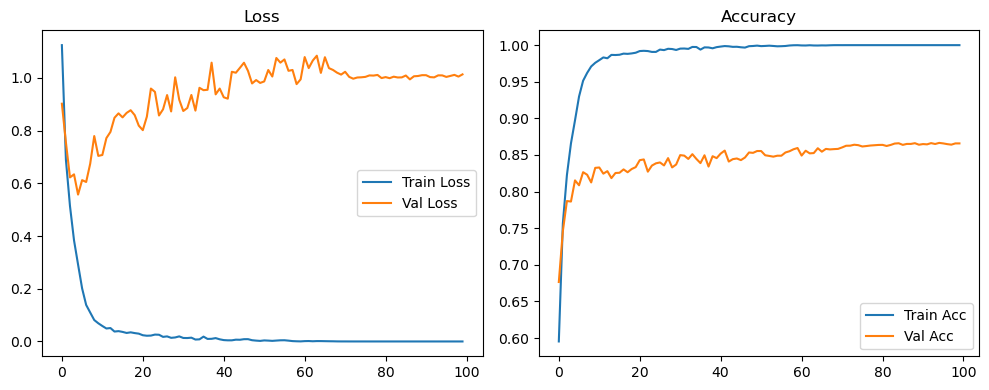

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.53it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.57it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.11it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  1.92it/s]

...

| LR: 0.000011 | Train Acc: 0.9999 | Val Acc: 0.8628 |:  99%|█████████▉| 99/100 [06:14<00:03,  3.79s/it]

| LR: 0.000010 | Train Acc: 0.9999 | Val Acc: 0.8614 |:  99%|█████████▉| 99/100 [06:18<00:03,  3.79s/it]

| LR: 0.000010 | Train Acc: 0.9999 | Val Acc: 0.8614 |:  99%|█████████▉| 99/100 [06:18<00:03,  3.79s/it]

| LR: 0.000010 | Train Acc: 0.9999 | Val Acc: 0.8614 |: 100%|██████████| 100/100 [06:18<00:00,  3.79s/it]

| LR: 0.000010 | Train Acc: 0.9999 | Val Acc: 0.8614 |: 100%|██████████| 100/100 [06:18<00:00,  3.79s/it]

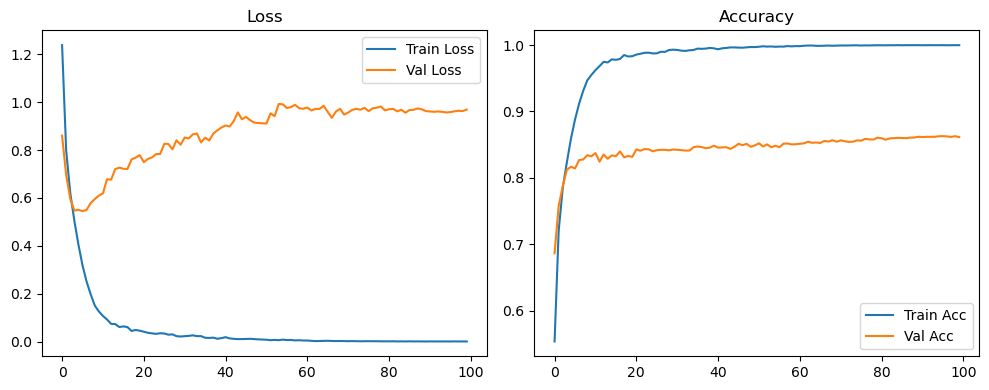

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.51it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.56it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.11it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  1.92it/s]

...

| LR: 0.000011 | Train Acc: 0.9995 | Val Acc: 0.8561 |:  99%|█████████▉| 99/100 [06:14<00:03,  3.78s/it]

| LR: 0.000010 | Train Acc: 0.9997 | Val Acc: 0.8548 |:  99%|█████████▉| 99/100 [06:18<00:03,  3.78s/it]

| LR: 0.000010 | Train Acc: 0.9997 | Val Acc: 0.8548 |:  99%|█████████▉| 99/100 [06:18<00:03,  3.78s/it]

| LR: 0.000010 | Train Acc: 0.9997 | Val Acc: 0.8548 |: 100%|██████████| 100/100 [06:18<00:00,  3.78s/it]

| LR: 0.000010 | Train Acc: 0.9997 | Val Acc: 0.8548 |: 100%|██████████| 100/100 [06:18<00:00,  3.78s/it]

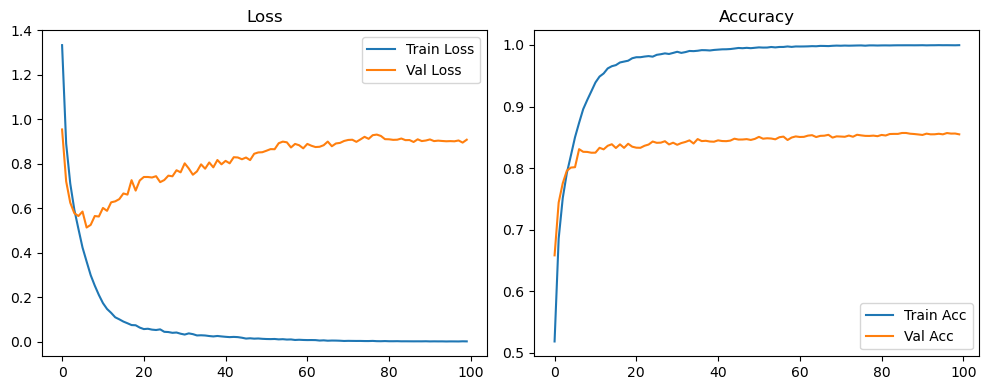

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.50it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.55it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.08it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  1.89it/s]

...

| LR: 0.000002 | Train Acc: 1.0000 | Val Acc: 0.8666 |:  99%|█████████▉| 99/100 [05:46<00:03,  3.50s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.8673 |:  99%|█████████▉| 99/100 [05:49<00:03,  3.50s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.8673 |:  99%|█████████▉| 99/100 [05:49<00:03,  3.50s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.8673 |: 100%|██████████| 100/100 [05:49<00:00,  3.49s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.8673 |: 100%|██████████| 100/100 [05:49<00:00,  3.50s/it]

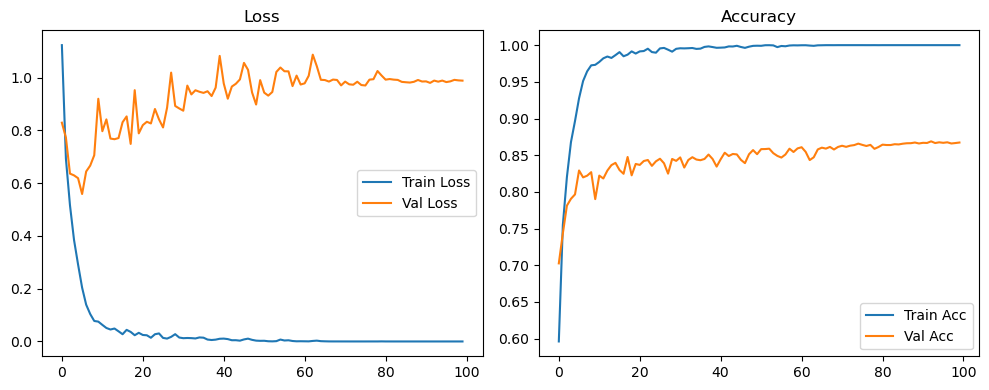

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.52it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.56it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.09it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  1.90it/s]

...

| LR: 0.000002 | Train Acc: 0.9999 | Val Acc: 0.8637 |:  99%|█████████▉| 99/100 [06:15<00:03,  3.79s/it]

| LR: 0.000001 | Train Acc: 0.9999 | Val Acc: 0.8630 |:  99%|█████████▉| 99/100 [06:18<00:03,  3.79s/it]

| LR: 0.000001 | Train Acc: 0.9999 | Val Acc: 0.8630 |:  99%|█████████▉| 99/100 [06:18<00:03,  3.79s/it]

| LR: 0.000001 | Train Acc: 0.9999 | Val Acc: 0.8630 |: 100%|██████████| 100/100 [06:18<00:00,  3.79s/it]

| LR: 0.000001 | Train Acc: 0.9999 | Val Acc: 0.8630 |: 100%|██████████| 100/100 [06:18<00:00,  3.79s/it]

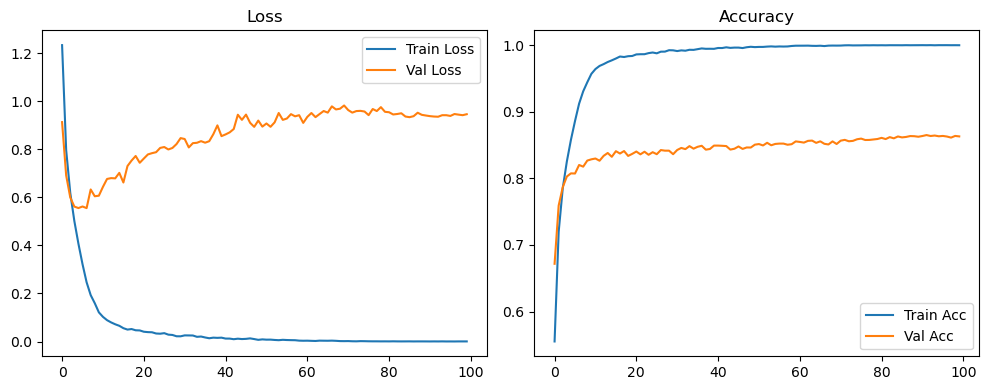

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.28it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.44it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  1.98it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  1.77it/s]

...

| LR: 0.000002 | Train Acc: 0.9996 | Val Acc: 0.8571 |:  99%|█████████▉| 99/100 [06:14<00:03,  3.78s/it]

| LR: 0.000001 | Train Acc: 0.9998 | Val Acc: 0.8583 |:  99%|█████████▉| 99/100 [06:18<00:03,  3.78s/it]

| LR: 0.000001 | Train Acc: 0.9998 | Val Acc: 0.8583 |:  99%|█████████▉| 99/100 [06:18<00:03,  3.78s/it]

| LR: 0.000001 | Train Acc: 0.9998 | Val Acc: 0.8583 |: 100%|██████████| 100/100 [06:18<00:00,  3.77s/it]

| LR: 0.000001 | Train Acc: 0.9998 | Val Acc: 0.8583 |: 100%|██████████| 100/100 [06:18<00:00,  3.78s/it]

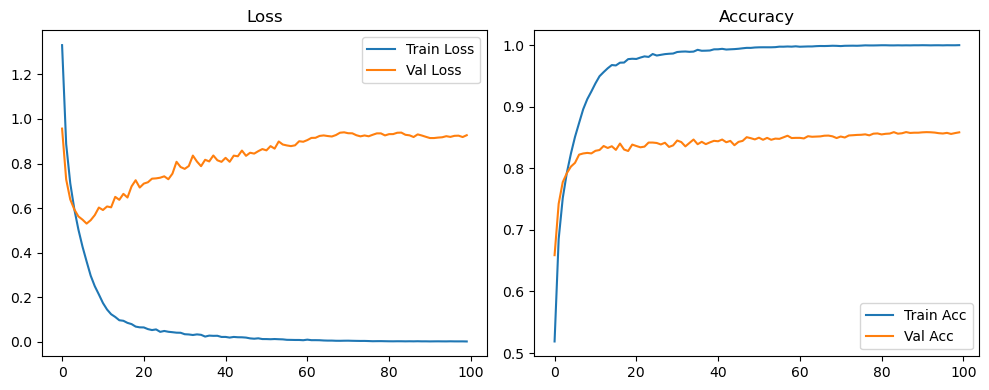

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.50it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.54it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.08it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  1.89it/s]

...

| LR: 0.000010 | Train Acc: 1.0000 | Val Acc: 0.8533 |:  99%|█████████▉| 99/100 [05:46<00:03,  3.50s/it]

| LR: 0.000010 | Train Acc: 1.0000 | Val Acc: 0.8532 |:  99%|█████████▉| 99/100 [05:49<00:03,  3.50s/it]

| LR: 0.000010 | Train Acc: 1.0000 | Val Acc: 0.8532 |:  99%|█████████▉| 99/100 [05:49<00:03,  3.50s/it]

| LR: 0.000010 | Train Acc: 1.0000 | Val Acc: 0.8532 |: 100%|██████████| 100/100 [05:49<00:00,  3.50s/it]

| LR: 0.000010 | Train Acc: 1.0000 | Val Acc: 0.8532 |: 100%|██████████| 100/100 [05:49<00:00,  3.50s/it]

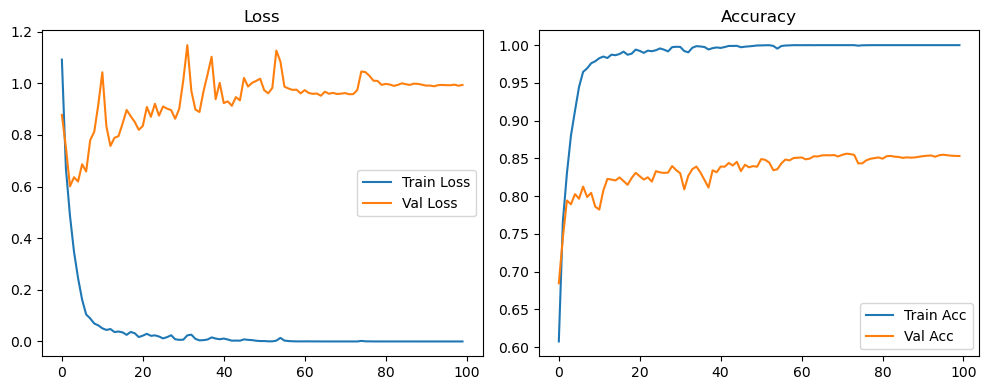

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.51it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.56it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.10it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  1.91it/s]

...

| LR: 0.000010 | Train Acc: 0.9999 | Val Acc: 0.8557 |:  99%|█████████▉| 99/100 [06:15<00:03,  3.75s/it]

| LR: 0.000010 | Train Acc: 0.9999 | Val Acc: 0.8548 |:  99%|█████████▉| 99/100 [06:19<00:03,  3.75s/it]

| LR: 0.000010 | Train Acc: 0.9999 | Val Acc: 0.8548 |:  99%|█████████▉| 99/100 [06:19<00:03,  3.75s/it]

| LR: 0.000010 | Train Acc: 0.9999 | Val Acc: 0.8548 |: 100%|██████████| 100/100 [06:19<00:00,  3.76s/it]

| LR: 0.000010 | Train Acc: 0.9999 | Val Acc: 0.8548 |: 100%|██████████| 100/100 [06:19<00:00,  3.79s/it]

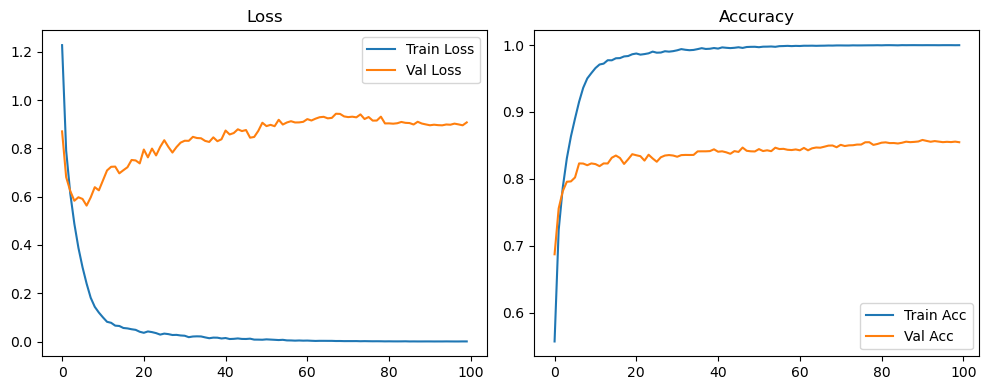

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.25it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.42it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  1.96it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  1.75it/s]

...

| LR: 0.000010 | Train Acc: 0.9998 | Val Acc: 0.8552 |:  99%|█████████▉| 99/100 [06:15<00:03,  3.79s/it]

| LR: 0.000010 | Train Acc: 0.9995 | Val Acc: 0.8534 |:  99%|█████████▉| 99/100 [06:18<00:03,  3.79s/it]

| LR: 0.000010 | Train Acc: 0.9995 | Val Acc: 0.8534 |:  99%|█████████▉| 99/100 [06:18<00:03,  3.79s/it]

| LR: 0.000010 | Train Acc: 0.9995 | Val Acc: 0.8534 |: 100%|██████████| 100/100 [06:18<00:00,  3.79s/it]

| LR: 0.000010 | Train Acc: 0.9995 | Val Acc: 0.8534 |: 100%|██████████| 100/100 [06:18<00:00,  3.79s/it]

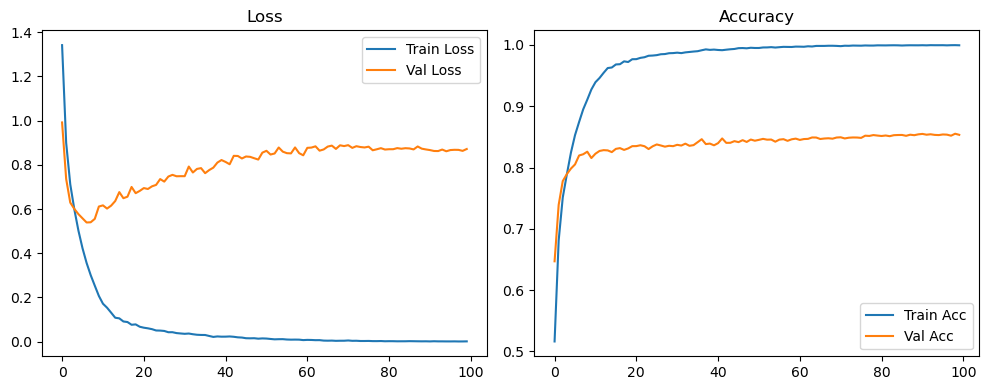

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.49it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.55it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.09it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  1.90it/s]

...

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.8550 |:  99%|█████████▉| 99/100 [05:45<00:03,  3.48s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.8553 |:  99%|█████████▉| 99/100 [05:49<00:03,  3.48s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.8553 |:  99%|█████████▉| 99/100 [05:49<00:03,  3.48s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.8553 |: 100%|██████████| 100/100 [05:49<00:00,  3.47s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.8553 |: 100%|██████████| 100/100 [05:49<00:00,  3.49s/it]

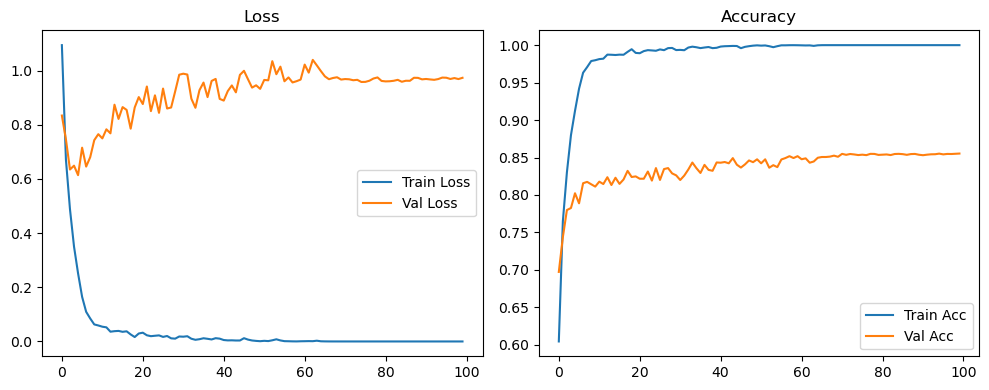

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.52it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.56it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.10it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  1.91it/s]

...

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.8585 |:  99%|█████████▉| 99/100 [06:15<00:03,  3.79s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.8578 |:  99%|█████████▉| 99/100 [06:19<00:03,  3.79s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.8578 |:  99%|█████████▉| 99/100 [06:19<00:03,  3.79s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.8578 |: 100%|██████████| 100/100 [06:19<00:00,  3.79s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.8578 |: 100%|██████████| 100/100 [06:19<00:00,  3.79s/it]

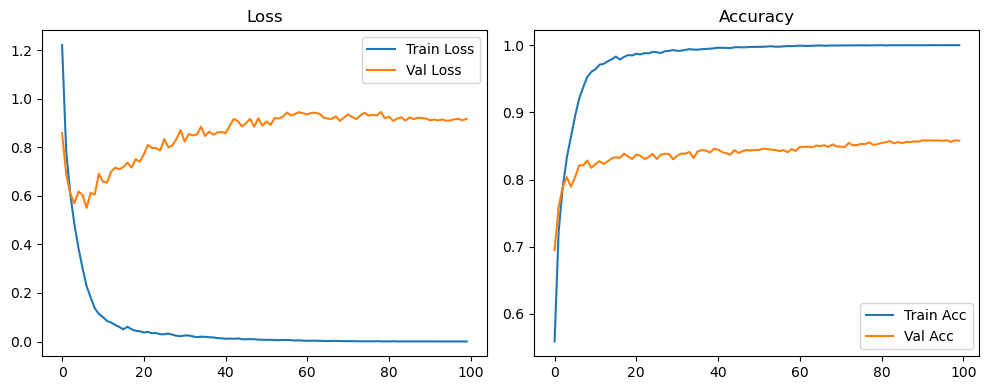

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.54it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.56it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.10it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  1.92it/s]

...

| LR: 0.000001 | Train Acc: 0.9997 | Val Acc: 0.8535 |:  99%|█████████▉| 99/100 [06:15<00:03,  3.78s/it]

| LR: 0.000001 | Train Acc: 0.9996 | Val Acc: 0.8527 |:  99%|█████████▉| 99/100 [06:18<00:03,  3.78s/it]

| LR: 0.000001 | Train Acc: 0.9996 | Val Acc: 0.8527 |:  99%|█████████▉| 99/100 [06:18<00:03,  3.78s/it]

| LR: 0.000001 | Train Acc: 0.9996 | Val Acc: 0.8527 |: 100%|██████████| 100/100 [06:18<00:00,  3.78s/it]

| LR: 0.000001 | Train Acc: 0.9996 | Val Acc: 0.8527 |: 100%|██████████| 100/100 [06:18<00:00,  3.79s/it]

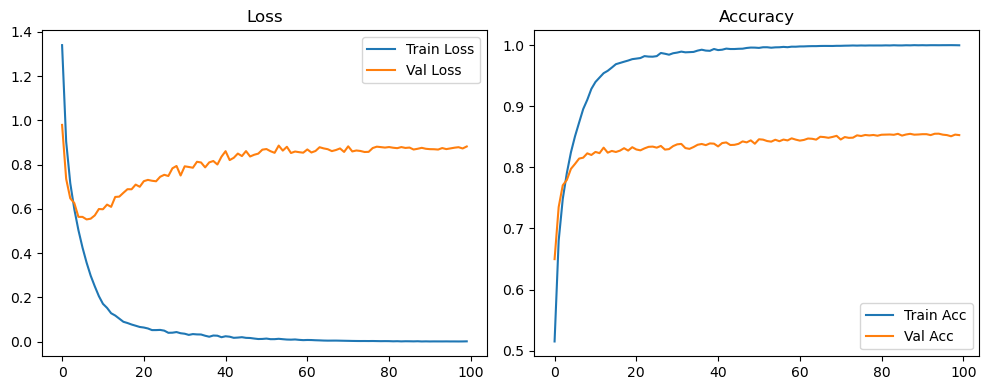

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.51it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.56it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.10it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  1.91it/s]

...

| LR: 0.000011 | Train Acc: 1.0000 | Val Acc: 0.8584 |:  99%|█████████▉| 99/100 [05:21<00:03,  3.24s/it]

| LR: 0.000010 | Train Acc: 1.0000 | Val Acc: 0.8577 |:  99%|█████████▉| 99/100 [05:24<00:03,  3.24s/it]

| LR: 0.000010 | Train Acc: 1.0000 | Val Acc: 0.8577 |:  99%|█████████▉| 99/100 [05:24<00:03,  3.24s/it]

| LR: 0.000010 | Train Acc: 1.0000 | Val Acc: 0.8577 |: 100%|██████████| 100/100 [05:24<00:00,  3.23s/it]

| LR: 0.000010 | Train Acc: 1.0000 | Val Acc: 0.8577 |: 100%|██████████| 100/100 [05:24<00:00,  3.25s/it]

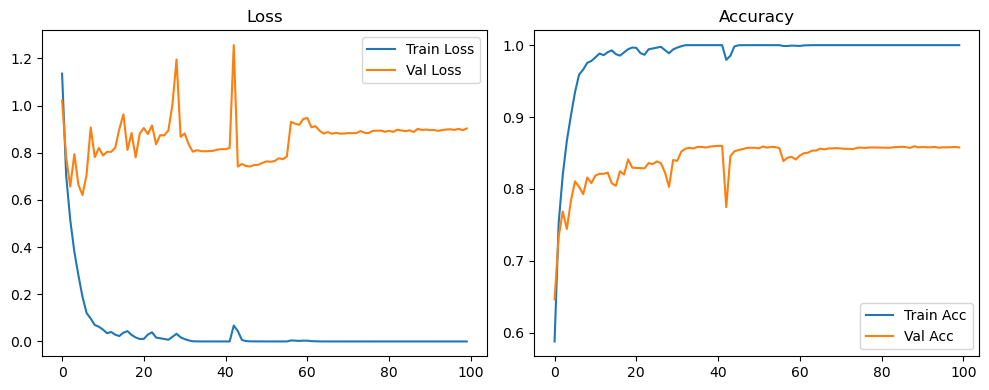

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.27it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.42it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  1.96it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  1.75it/s]

...

| LR: 0.000011 | Train Acc: 1.0000 | Val Acc: 0.8552 |:  99%|█████████▉| 99/100 [05:48<00:03,  3.49s/it]

| LR: 0.000010 | Train Acc: 0.9999 | Val Acc: 0.8550 |:  99%|█████████▉| 99/100 [05:51<00:03,  3.49s/it]

| LR: 0.000010 | Train Acc: 0.9999 | Val Acc: 0.8550 |:  99%|█████████▉| 99/100 [05:51<00:03,  3.49s/it]

| LR: 0.000010 | Train Acc: 0.9999 | Val Acc: 0.8550 |: 100%|██████████| 100/100 [05:51<00:00,  3.50s/it]

| LR: 0.000010 | Train Acc: 0.9999 | Val Acc: 0.8550 |: 100%|██████████| 100/100 [05:51<00:00,  3.52s/it]

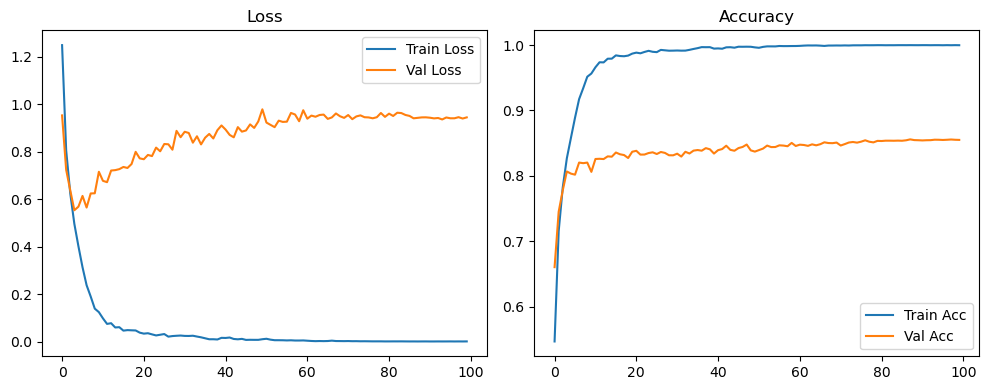

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.52it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.57it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.11it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  1.92it/s]

...

| LR: 0.000011 | Train Acc: 0.9996 | Val Acc: 0.8551 |:  99%|█████████▉| 99/100 [05:47<00:03,  3.50s/it]

| LR: 0.000010 | Train Acc: 0.9998 | Val Acc: 0.8542 |:  99%|█████████▉| 99/100 [05:50<00:03,  3.50s/it]

| LR: 0.000010 | Train Acc: 0.9998 | Val Acc: 0.8542 |:  99%|█████████▉| 99/100 [05:50<00:03,  3.50s/it]

| LR: 0.000010 | Train Acc: 0.9998 | Val Acc: 0.8542 |: 100%|██████████| 100/100 [05:50<00:00,  3.50s/it]

| LR: 0.000010 | Train Acc: 0.9998 | Val Acc: 0.8542 |: 100%|██████████| 100/100 [05:50<00:00,  3.51s/it]

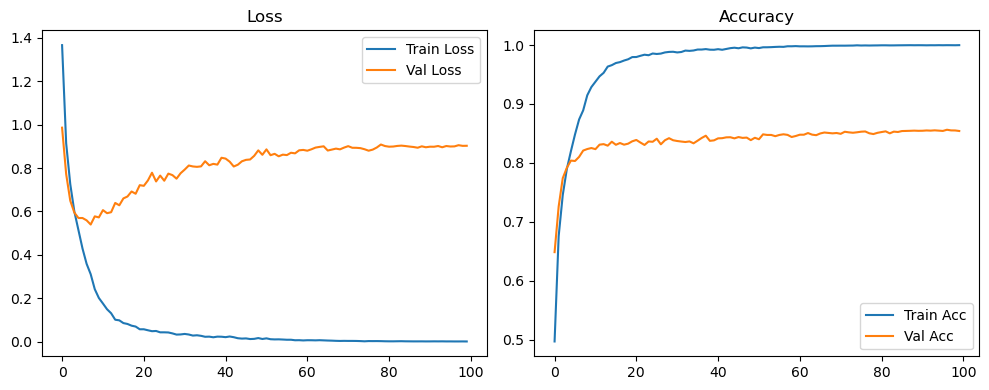

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.50it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.54it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.08it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  1.89it/s]

...

| LR: 0.000002 | Train Acc: 1.0000 | Val Acc: 0.8611 |:  99%|█████████▉| 99/100 [05:21<00:03,  3.24s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.8615 |:  99%|█████████▉| 99/100 [05:24<00:03,  3.24s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.8615 |:  99%|█████████▉| 99/100 [05:24<00:03,  3.24s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.8615 |: 100%|██████████| 100/100 [05:24<00:00,  3.24s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.8615 |: 100%|██████████| 100/100 [05:24<00:00,  3.24s/it]

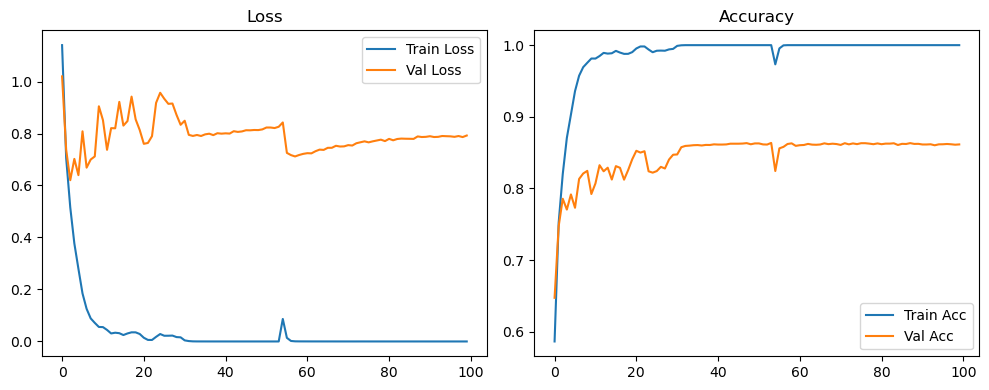

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.26it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.44it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  1.98it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  1.77it/s]

...

| LR: 0.000002 | Train Acc: 1.0000 | Val Acc: 0.8588 |:  99%|█████████▉| 99/100 [05:47<00:03,  3.51s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.8580 |:  99%|█████████▉| 99/100 [05:50<00:03,  3.51s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.8580 |:  99%|█████████▉| 99/100 [05:50<00:03,  3.51s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.8580 |: 100%|██████████| 100/100 [05:51<00:00,  3.51s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.8580 |: 100%|██████████| 100/100 [05:51<00:00,  3.51s/it]

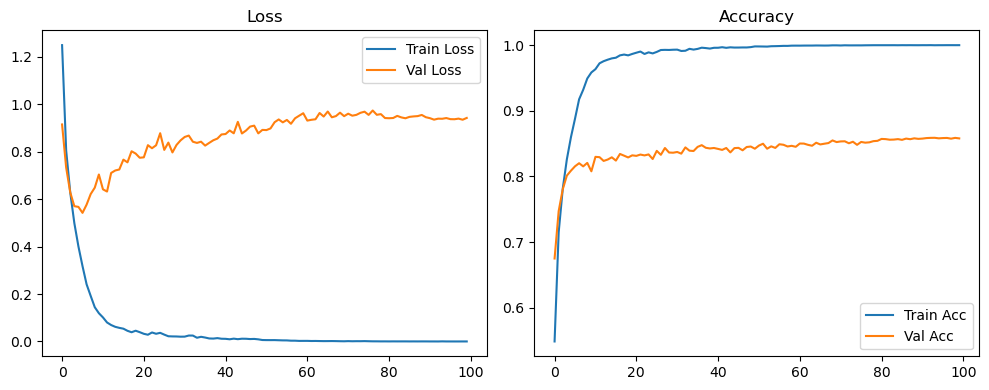

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.52it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.57it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.11it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  1.92it/s]

...

| LR: 0.000002 | Train Acc: 0.9998 | Val Acc: 0.8525 |:  99%|█████████▉| 99/100 [05:47<00:03,  3.50s/it]

| LR: 0.000001 | Train Acc: 0.9997 | Val Acc: 0.8523 |:  99%|█████████▉| 99/100 [05:50<00:03,  3.50s/it]

| LR: 0.000001 | Train Acc: 0.9997 | Val Acc: 0.8523 |:  99%|█████████▉| 99/100 [05:50<00:03,  3.50s/it]

| LR: 0.000001 | Train Acc: 0.9997 | Val Acc: 0.8523 |: 100%|██████████| 100/100 [05:50<00:00,  3.50s/it]

| LR: 0.000001 | Train Acc: 0.9997 | Val Acc: 0.8523 |: 100%|██████████| 100/100 [05:50<00:00,  3.51s/it]

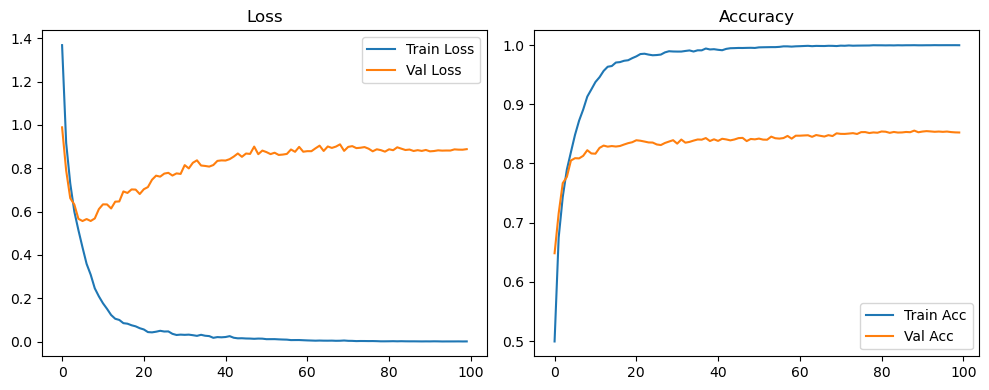

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.51it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.55it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.08it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  1.90it/s]

...

| LR: 0.000010 | Train Acc: 1.0000 | Val Acc: 0.8515 |:  99%|█████████▉| 99/100 [05:22<00:03,  3.25s/it]

| LR: 0.000010 | Train Acc: 1.0000 | Val Acc: 0.8512 |:  99%|█████████▉| 99/100 [05:25<00:03,  3.25s/it]

| LR: 0.000010 | Train Acc: 1.0000 | Val Acc: 0.8512 |:  99%|█████████▉| 99/100 [05:25<00:03,  3.25s/it]

| LR: 0.000010 | Train Acc: 1.0000 | Val Acc: 0.8512 |: 100%|██████████| 100/100 [05:25<00:00,  3.25s/it]

| LR: 0.000010 | Train Acc: 1.0000 | Val Acc: 0.8512 |: 100%|██████████| 100/100 [05:25<00:00,  3.25s/it]

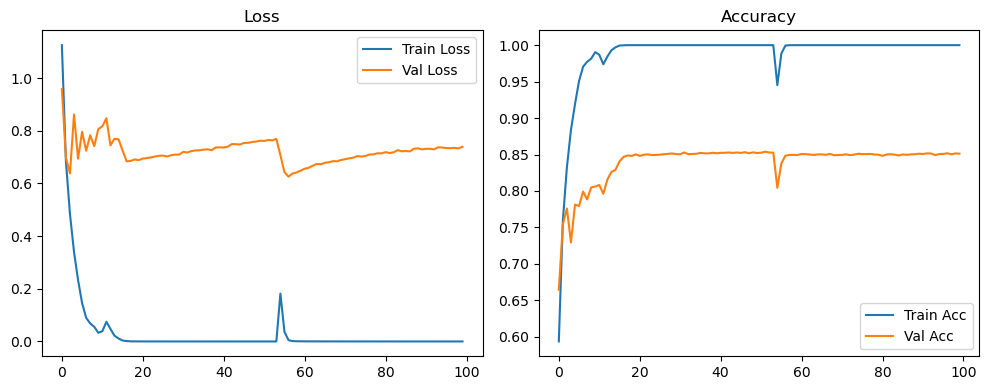

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.52it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.56it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.10it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  1.91it/s]

...

| LR: 0.000010 | Train Acc: 0.9999 | Val Acc: 0.8502 |:  99%|█████████▉| 99/100 [05:47<00:03,  3.51s/it]

| LR: 0.000010 | Train Acc: 1.0000 | Val Acc: 0.8485 |:  99%|█████████▉| 99/100 [05:50<00:03,  3.51s/it]

| LR: 0.000010 | Train Acc: 1.0000 | Val Acc: 0.8485 |:  99%|█████████▉| 99/100 [05:50<00:03,  3.51s/it]

| LR: 0.000010 | Train Acc: 1.0000 | Val Acc: 0.8485 |: 100%|██████████| 100/100 [05:50<00:00,  3.51s/it]

| LR: 0.000010 | Train Acc: 1.0000 | Val Acc: 0.8485 |: 100%|██████████| 100/100 [05:50<00:00,  3.51s/it]

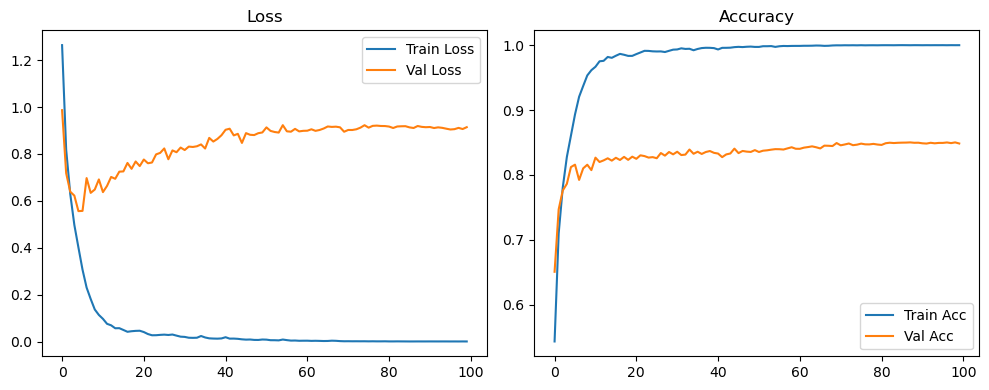

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.50it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.55it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.10it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  1.91it/s]

...

| LR: 0.000010 | Train Acc: 0.9998 | Val Acc: 0.8472 |:  99%|█████████▉| 99/100 [05:47<00:03,  3.50s/it]

| LR: 0.000010 | Train Acc: 0.9998 | Val Acc: 0.8482 |:  99%|█████████▉| 99/100 [05:51<00:03,  3.50s/it]

| LR: 0.000010 | Train Acc: 0.9998 | Val Acc: 0.8482 |:  99%|█████████▉| 99/100 [05:51<00:03,  3.50s/it]

| LR: 0.000010 | Train Acc: 0.9998 | Val Acc: 0.8482 |: 100%|██████████| 100/100 [05:51<00:00,  3.50s/it]

| LR: 0.000010 | Train Acc: 0.9998 | Val Acc: 0.8482 |: 100%|██████████| 100/100 [05:51<00:00,  3.51s/it]

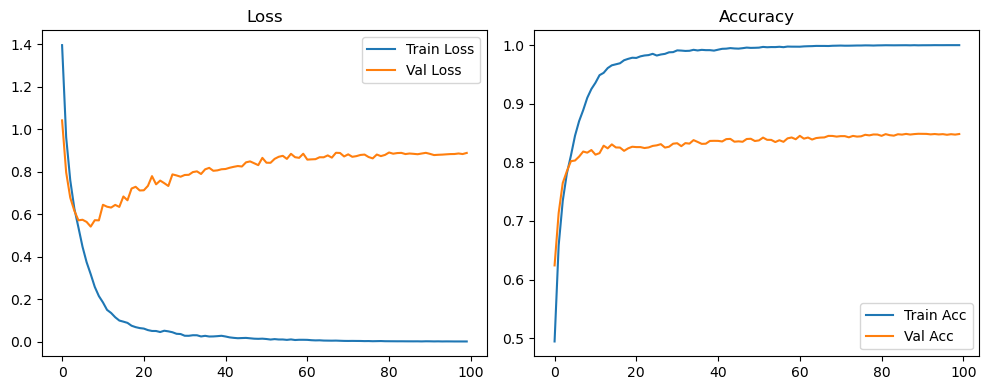

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.51it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.38it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  1.92it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  1.75it/s]

...

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.8530 |:  99%|█████████▉| 99/100 [05:21<00:03,  3.24s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.8525 |:  99%|█████████▉| 99/100 [05:24<00:03,  3.24s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.8525 |:  99%|█████████▉| 99/100 [05:24<00:03,  3.24s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.8525 |: 100%|██████████| 100/100 [05:24<00:00,  3.24s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.8525 |: 100%|██████████| 100/100 [05:24<00:00,  3.24s/it]

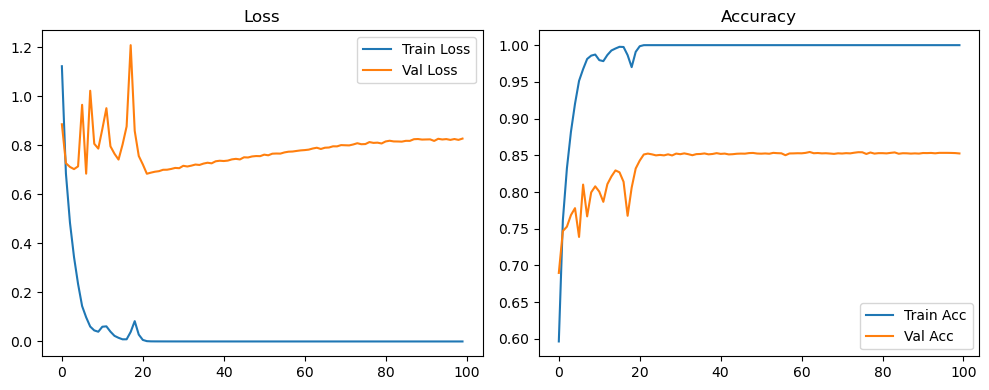

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.51it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.55it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.10it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  1.91it/s]

...

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.8507 |:  99%|█████████▉| 99/100 [05:47<00:03,  3.52s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.8497 |:  99%|█████████▉| 99/100 [05:50<00:03,  3.52s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.8497 |:  99%|█████████▉| 99/100 [05:50<00:03,  3.52s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.8497 |: 100%|██████████| 100/100 [05:50<00:00,  3.51s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.8497 |: 100%|██████████| 100/100 [05:50<00:00,  3.51s/it]

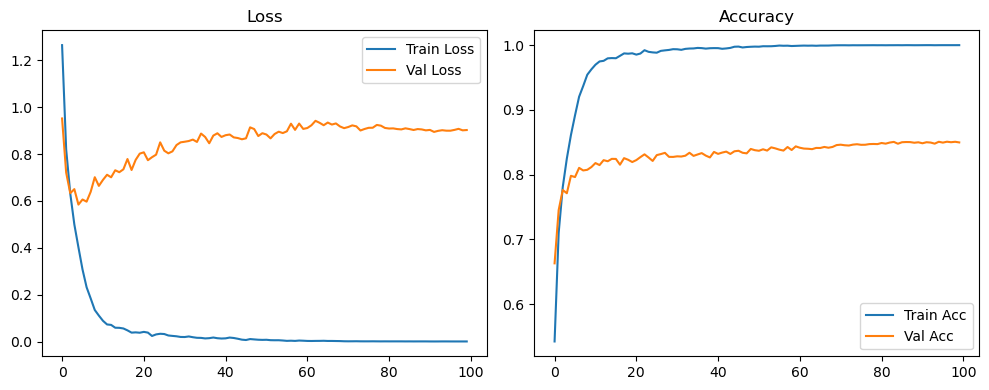

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.51it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.55it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.09it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  1.90it/s]

...

| LR: 0.000001 | Train Acc: 0.9997 | Val Acc: 0.8515 |:  99%|█████████▉| 99/100 [05:47<00:03,  3.51s/it]

| LR: 0.000001 | Train Acc: 0.9996 | Val Acc: 0.8496 |:  99%|█████████▉| 99/100 [05:50<00:03,  3.51s/it]

| LR: 0.000001 | Train Acc: 0.9996 | Val Acc: 0.8496 |:  99%|█████████▉| 99/100 [05:50<00:03,  3.51s/it]

| LR: 0.000001 | Train Acc: 0.9996 | Val Acc: 0.8496 |: 100%|██████████| 100/100 [05:51<00:00,  3.51s/it]

| LR: 0.000001 | Train Acc: 0.9996 | Val Acc: 0.8496 |: 100%|██████████| 100/100 [05:51<00:00,  3.51s/it]

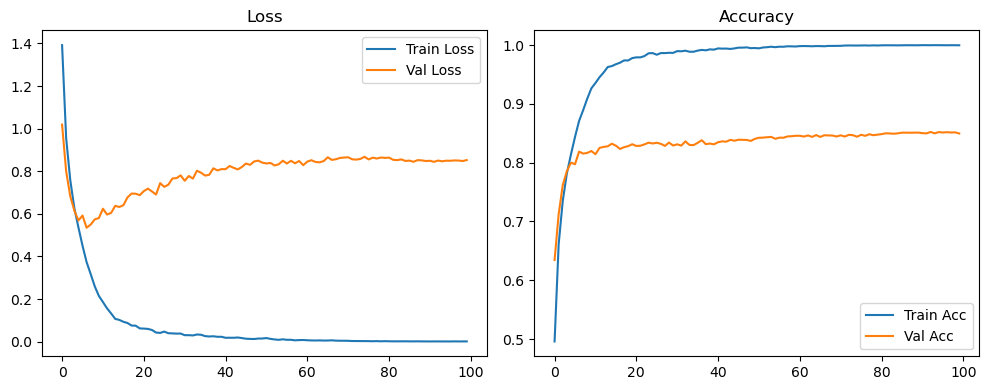

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.51it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.55it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.10it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  1.91it/s]

Original Model Final Test Loss: 0.9363 Accuracy: 0.8425


🏆 Best Config: batch128_lr_max_0.001_min_1e-05_dp0.0 Accuracy: 0.8630


In [16]:
Hyperparameter_searching(epochs, batch_sizes, lr_max_pool, lr_min_pool, dropout_rates)